## Topic : Factors Influencing Public Trust in Society

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
data = pd.read_csv("data.csv")
data1 = pd.read_csv("data1.csv")
data2 = pd.read_csv("data2.csv")
data3 = pd.read_csv("data3.csv")

data y (outcome) : Percentage of population who think most people can be trusted

x1 : GDP rate per capita

In [58]:
data.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public


In [59]:
print(data.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID',
       'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE',
       'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS',
       'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')


### Cleaning the data (y)

In [60]:
df = data[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
df.columns = ['Country', 'Year', 'Trust']
df = df.dropna()
df

,Country,Year,Trust
0,Andorra,2018,23.214285
1,Andorra,2018,23.308271
2,Andorra,2018,25.714287
3,Andorra,2018,30.239519
4,Andorra,2018,28.054300
...,...,...,...
1634,Zimbabwe,2021,2.478915
1635,Zimbabwe,2021,3.826917
1636,Zimbabwe,2021,3.725705
1637,Zimbabwe,2021,2.749519


### Filter only total population

In [61]:
print(data['SEX_LABEL'].unique())
print(data['AGE_LABEL'].unique())

['Total' 'Male' 'Female']
['All age ranges or no breakdown by age' '60 years old and over'
 '25 years old and over' '15 to 24 years old' '30 to 59 years old'
 '15 to 29 years old']


In [62]:
df = data[
    (data['SEX_LABEL'] == 'Total') &
    (data['AGE_LABEL'] == 'All age ranges or no breakdown by age') &
    (data['URBANISATION_LABEL'] == 'Total')
][['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]

df.columns = ['Country', 'Year', 'Trust']

# Filter year range 2015-2022
df = df[(df['Year'] >= 2015) & (df['Year'] <= 2022)]

df = df.groupby(['Country', 'Year'])['Trust'].mean().reset_index()
df['Country'] = df['Country'].replace({
    'Viet Nam': 'Vietnam'
})

In [63]:
df

,Country,Year,Trust
0,Andorra,2018,30.130722
1,Angola,2020,14.984976
2,Argentina,2018,19.855508
3,Argentina,2020,16.553906
4,Armenia,2021,10.870762
...,...,...,...
114,"Venezuela, RB",2018,7.195456
115,"Venezuela, RB",2020,5.143149
116,Vietnam,2018,29.356374
117,Zambia,2020,7.408481


In [64]:
df['Country'].unique()

array(['Andorra', 'Angola', 'Argentina', 'Armenia', 'Australia',
       'Bangladesh', 'Benin', 'Bolivia', 'Botswana', 'Brazil',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', "Cote d'Ivoire",
       'Cyprus', 'Czechia', 'Dominican Republic', 'Ecuador',
       'El Salvador', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The',
       'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Haiti', 'Honduras',
       'Hong Kong SAR, China', 'India', 'Indonesia', 'Iran, Islamic Rep.',
       'Japan', 'Kazakhstan', 'Kenya', 'Korea, Rep.', 'Kyrgyz Republic',
       'Lesotho', 'Liberia', 'Macao SAR, China', 'Malawi', 'Malaysia',
       'Maldives', 'Mali', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco',
       'Mozambique', 'Myanmar', 'Namibia', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Niger', 'Nigeria', 'Pakistan', 'Panama', 'Paraguay',
       'Peru', 'Philippines', 'Puerto Rico', 'Romania',
       'Russian Federation', 'Senegal

data1 x1 : GDP rate per capita

In [65]:
data1.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VEN,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VNM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [66]:
print(data1.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'AGG_METHOD',
       'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS',
       'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_VALUE', 'OBS_STATUS',
       'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL',
       'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL',
       'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL',
       'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL'],
      dtype='object')


In [67]:
gdp_data = data1[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
gdp_data.columns = ['Country', 'Year', 'GDP']
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2011,4.176425
1,Vietnam,2011,6.413169
2,Virgin Islands (U.S.),2011,-8.204246
3,West Bank and Gaza,2011,9.600808
4,"Yemen, Rep.",2011,-12.714897
...,...,...,...
14128,"Venezuela, RB",2024,5.300000
14129,Vietnam,2024,7.091187
14130,West Bank and Gaza,2024,-26.557526
14131,Zambia,2024,3.820048


In [68]:
gdp_data = gdp_data[(gdp_data['Year'] >= 2015) & (gdp_data['Year'] <= 2022)]
gdp_data

,Country,Year,GDP
47,Eastern & Southern Africa,2015,2.934030
48,Western & Central Africa,2015,2.932864
49,Arab World,2015,3.350804
50,Caribbean small states,2015,-0.100918
102,Uzbekistan,2018,5.559196
...,...,...,...
8074,"Middle East, North Africa, Afghanistan & Pakistan",2022,6.446529
8075,"Middle East, North Africa, Afghanistan & Pakis...",2022,4.329722
8076,"Middle East, North Africa, Afghanistan & Pakis...",2022,4.331551
8077,Middle income,2022,4.007290


In [69]:
valid_countries = df['Country'].unique()
gdp_data = gdp_data[gdp_data['Country'].isin(valid_countries)]
gdp_data = gdp_data.reset_index(drop=True)

In [70]:
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2018,-19.655342
1,Vietnam,2018,7.465007
2,Zambia,2018,4.034494
3,Zimbabwe,2018,5.009922
4,El Salvador,2016,2.539062
...,...,...,...
723,El Salvador,2022,2.954615
724,Eswatini,2022,0.386071
725,Ethiopia,2022,5.321760
726,Andorra,2021,8.286779


x2 : Expected years of schooling

In [71]:
data2.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,...,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,ABW,Aruba,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFE,Africa Eastern and Southern,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFG,Afghanistan,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFW,Africa Western and Central,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AGO,Angola,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public


In [72]:
edu_clean = data2[data2['SEX_ID'] == '_T']

In [73]:
edu_clean = edu_clean[['REF_AREA_NAME', 'TIME_PERIOD', 'OBS_VALUE']]
edu_clean.columns = ['Country', 'Year', 'Education']

In [74]:
edu_clean = edu_clean[(edu_clean['Year'] >= 2015) & (edu_clean['Year'] <= 2022)]
edu_clean = edu_clean.dropna()
edu_clean

,Country,Year,Education
43726,Africa Eastern and Southern,2015,9.41692
43728,Africa Western and Central,2015,8.89208
43730,Albania,2015,15.91224
43731,Andorra,2015,11.80185
43732,Arab World,2015,10.90083
...,...,...,...
49525,Latin America & Caribbean (IDA & IBRD),2022,14.72962
49529,South Asia (IDA & IBRD),2022,11.66683
49538,Upper middle income,2022,14.93695
49544,British Virgin Islands,2022,13.75233


In [75]:
valid_countries = df['Country'].unique()
edu_clean = edu_clean[edu_clean['Country'].isin(valid_countries)]
edu_clean = edu_clean.reset_index(drop=True)

In [76]:
edu_clean

,Country,Year,Education
0,Andorra,2015,11.801850
1,Argentina,2015,17.584660
2,Armenia,2015,13.132490
3,Australia,2015,23.247681
4,Benin,2015,12.346910
...,...,...,...
339,India,2022,12.583710
340,"Macao SAR, China",2022,15.586020
341,Morocco,2022,14.594420
342,Senegal,2022,9.144550


X3 : Unemployment rate

In [77]:
data3

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AND,Andorra,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,VNM,Viet Nam,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,F,Forecast value,PU,Public
9796,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,PSE,West Bank and Gaza,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
9797,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,YEM,"Yemen, Rep.",IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
9798,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZMB,Zambia,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public


In [78]:
data3.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'COMMENT_TS',
       'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL',
       'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS',
       'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')

In [79]:
unemp = data3[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp

,Country,Year,Unemployment
0,Afghanistan,1980,NaN
1,Albania,1980,5.028
2,Algeria,1980,15.789
3,Andorra,1980,NaN
4,Angola,1980,NaN
...,...,...,...
9795,Viet Nam,2029,1.933
9796,West Bank and Gaza,2029,NaN
9797,"Yemen, Rep.",2029,NaN
9798,Zambia,2029,NaN


In [80]:
unemp = unemp[(unemp['Year'] >= 2015) & (unemp['Year'] <= 2022)]
unemp = unemp.dropna()
unemp

,Country,Year,Unemployment
6861,Albania,2015,17.100
6862,Algeria,2015,11.214
6863,Andorra,2015,3.875
6866,Argentina,2015,6.533
6867,Armenia,2015,18.500
...,...,...,...
8418,United States,2022,3.633
8419,Uruguay,2022,7.867
8420,Uzbekistan,2022,8.851
8423,Viet Nam,2022,2.320


In [81]:
unemp = data3[data3['SEX'] == '_T']
unemp = unemp[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp = unemp[(unemp['Year'] >= 2015) & (unemp['Year'] <= 2022)].dropna()
unemp

,Country,Year,Unemployment
6861,Albania,2015,17.100
6862,Algeria,2015,11.214
6863,Andorra,2015,3.875
6866,Argentina,2015,6.533
6867,Armenia,2015,18.500
...,...,...,...
8418,United States,2022,3.633
8419,Uruguay,2022,7.867
8420,Uzbekistan,2022,8.851
8423,Viet Nam,2022,2.320


In [82]:
print(unemp.head())
print(len(unemp))
print(unemp['Country'].nunique())

        Country  Year  Unemployment
6861    Albania  2015        17.100
6862    Algeria  2015        11.214
6863    Andorra  2015         3.875
6866  Argentina  2015         6.533
6867    Armenia  2015        18.500
878
112


### Merge all Xs, with the union countries

In [83]:
gdp_data = gdp_data.drop(columns=['Year'])
edu_clean = edu_clean.drop(columns=['Year'])
unemp = unemp.drop(columns=['Year'])

In [84]:
df_final = df.copy()

df_final = pd.merge(df_final, gdp_data, on='Country')
df_final = pd.merge(df_final, edu_clean, on='Country')
df_final = pd.merge(df_final, unemp, on='Country')

In [85]:
# Group by Country and compute mean for all numeric columns
df_final = df_final.groupby('Country')[['Trust', 'GDP', 'Education', 'Unemployment']].mean().reset_index()
df_final

,Country,Trust,GDP,Education,Unemployment
0,Andorra,30.130722,1.970207,12.029040,2.712500
1,Argentina,18.204707,0.676644,18.081460,8.687500
2,Armenia,10.870762,4.362500,13.977807,17.287500
3,Australia,37.224962,2.300994,21.696950,5.390750
4,Brazil,4.805490,0.251022,15.417804,11.712500
5,Cabo Verde,8.357502,2.811847,12.148168,10.725000
6,Canada,45.684374,1.809385,15.951103,6.802000
7,Chile,14.935067,2.151564,16.539878,7.761000
8,Colombia,16.913874,2.887173,14.590004,11.366625
9,Costa Rica,9.860702,3.157677,15.128070,12.266875


In [86]:
df_final.to_csv('df_final.csv', index=False)

In [87]:
len(df_final)

49

### Try plotting graph for each independent variable

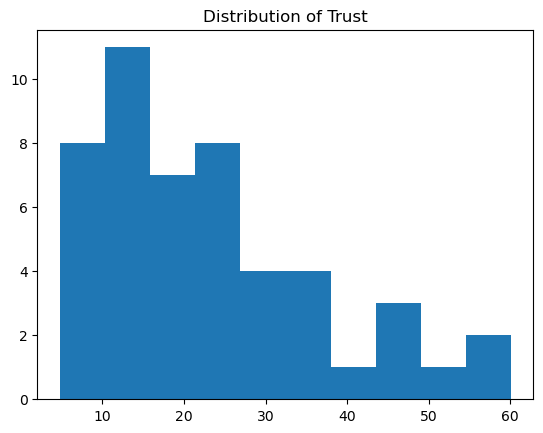

In [88]:
plt.hist(df_final['Trust'])
plt.title('Distribution of Trust')
plt.show()

### Trust VS GDP

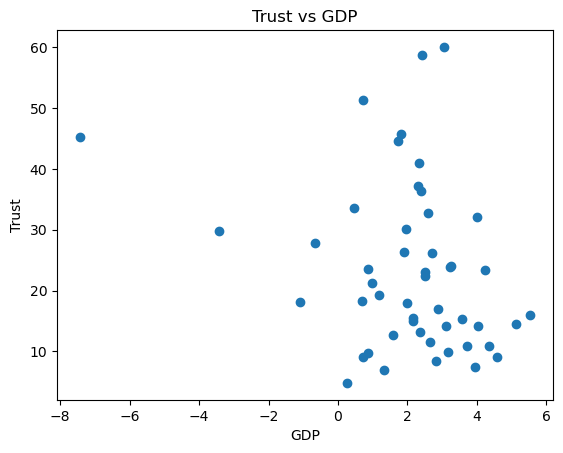

In [89]:
plt.scatter(df_final['GDP'], df_final['Trust'])
plt.xlabel('GDP')
plt.ylabel('Trust')
plt.title('Trust vs GDP')
plt.show()

### Trust VS Education

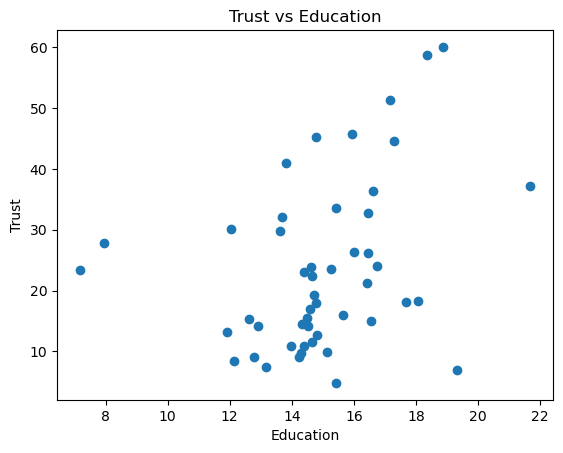

In [90]:
plt.scatter(df_final['Education'], df_final['Trust'])
plt.xlabel('Education')
plt.ylabel('Trust')
plt.title('Trust vs Education')
plt.show()

### Trust vs Unemployment

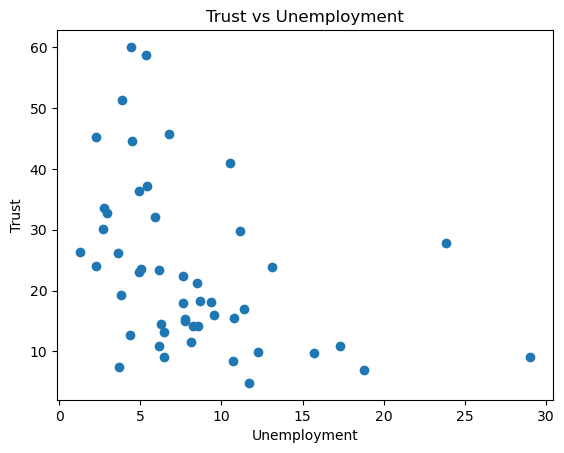

In [91]:
plt.scatter(df_final['Unemployment'], df_final['Trust'])
plt.xlabel('Unemployment')
plt.ylabel('Trust')
plt.title('Trust vs Unemployment')
plt.show()

### Try unemployment with log

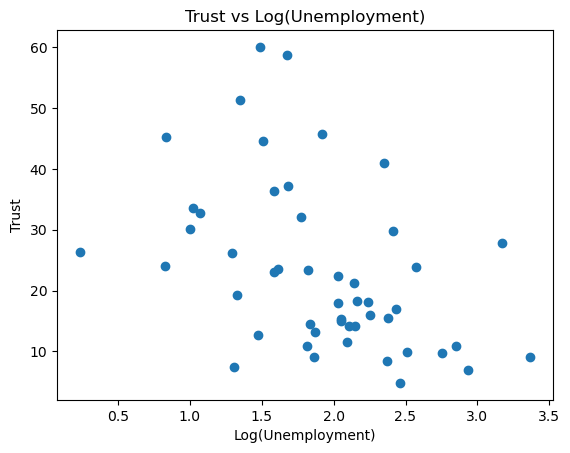

In [92]:
# Add log-transformed unemployment
df_final['Log_Unemployment'] = np.log(df_final['Unemployment'])

plt.scatter(df_final['Log_Unemployment'], df_final['Trust'])
plt.xlabel('Log(Unemployment)')
plt.ylabel('Trust')
plt.title('Trust vs Log(Unemployment)')
plt.show()

### We will use log(unemployment rate) since its relationship looks more linear than no-log(unemployment rate) that its relationship curves.

In [93]:
## Regression Analysis: Full Model and All Subset Models (Matrix Algebra Approach)

In [94]:
# Prepare data with log unemployment
df_reg = df_final.copy()
df_reg['Log_Unemployment'] = np.log(df_reg['Unemployment'])
df_reg = df_reg.drop(columns=['Unemployment'])

y = np.array(df_reg['Trust'])
gdp = np.array(df_reg['GDP'])
edu = np.array(df_reg['Education'])
log_unemp = np.array(df_reg['Log_Unemployment'])


In [ ]:
# Function to fit regression and compute R^²
def fit_regression(X, y):
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    
    # Calculate predictions and R^2
    y_pred = X @ beta
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Calculate adjusted R^2
    n = len(y)
    k = X.shape[1] - 1  # number of regressors (excluding intercept)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
    
    return beta, r_squared, adj_r_squared


In [107]:
# build the x matrix
X_full = np.c_[np.ones(len(y)), gdp, edu, log_unemp]
beta_full, r2_full, adj_r2_full = fit_regression(X_full, y)

print(f'beta_full : {beta_full}')
print(f'r2_full : {r2_full}')
print(f'adj_r2_full : {adj_r2_full}')

beta_full : [23.32336585 -1.44408605  1.25688315 -8.31434563]
r2_full : 0.3017910696735794
adj_r2_full : 0.255243807651818


### For the full model, it shows that higher GDP and unemployment are associated with lower trust, while more education leads to higher trust.